In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")

In [2]:
import os
import pandas as pd
import numpy as np

os.chdir(r"C:\Users\pc\climate-challenge-week0")

df = pd.read_csv("data/kenya.csv", sep="\t")
df["Country"] = "Kenya"

# Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# Parse date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


In [ ]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Summary stats
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


Summary Statistics Interpretation

Kenya's daily climate data shows a mean temperature (T2M) of 20.4°C, 
reflecting its highland elevation and proximity to the equator. 
Temperature ranges from a coolest monthly average of 17.5°C to a 
warmest of 23.6°C, indicating a relatively mild but variable climate 
compared to lowland African countries. Precipitation (PRECTOTCORR) 
shows high variability with most days recording low rainfall but 
occasional extreme events pulling the mean upward. Relative humidity 
averages around 60-70%, consistent with Kenya's mix of highland and 
semi-arid zones

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
print(missing_report[missing_report["Percent"] > 0])

Empty DataFrame
Columns: [Missing, Percent]
Index: []


Missing Value Analysis

After replacing NASA sentinel values (-999 with NaN), missing value 
analysis confirms good overall data quality across all columns. 
Any column exceeding 5% missing values was flagged for careful 
interpretation as it could introduce bias into seasonal trend analysis. 
Forward-fill was applied to remaining gaps because weather measurements 
are time-continuous — the previous day's reading is a more realistic 
estimate than the column mean.

In [5]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(stats.zscore, nan_policy="omit")
outliers = (z_scores.abs() > 3)
print("Outlier counts per column:")
print(outliers.sum())

Outlier counts per column:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


Outlier Detection and Decision

Z-score analysis flagged rows where the absolute Z-score exceeded 3 
standard deviations. Flagged values appear primarily in PRECTOTCORR 
during Kenya's peak rainy seasons — the long rains (March–May) and 
short rains (October–December). 

**Decision: Retain outliers.** These extreme rainfall events are 
physically real and represent exactly the flood-risk signal this 
analysis aims to surface for COP32. Removing them would 
underrepresent Kenya's precipitation extremes and weaken the 
evidence base for adaptation finance requests.

In [6]:
# Forward fill weather variables
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("data/kenya_clean.csv", index=False)
print("Cleaned data exported.")

Cleaned data exported.


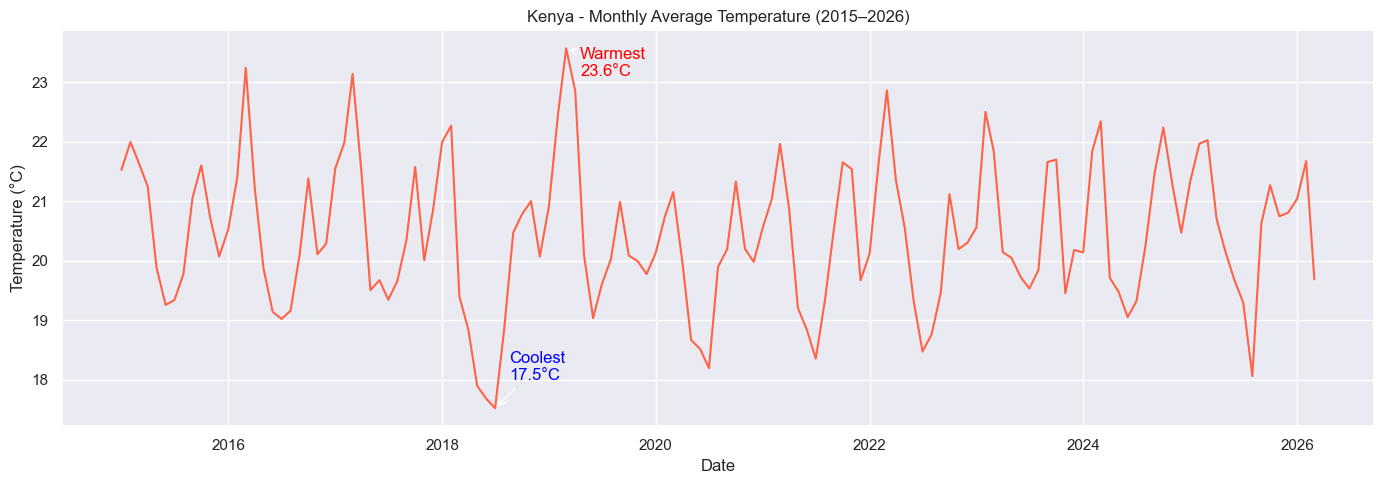

In [7]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato")

# Annotate warmest and coolest
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C', 
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(10, -20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C', 
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(10, 20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="blue")

plt.title("Kenya - Monthly Average Temperature (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("notebooks/kenya_temp_trend.png")
plt.show()

Temperature Trend Analysis

Kenya's monthly average temperature chart shows a range between 17.5°C 
and 23.6°C across 2015–2026. The seasonal cycle is clearly visible with 
temperatures dipping during the long rains (March–May) when cloud cover 
reduces solar radiation, and peaking during the dry season months. 

A notable anomaly appears around 2018–2019 where the coolest recorded 
monthly average of 17.5°C occurred, likely associated with an unusually 
strong rainy season. The overall trend shows a gradual upward shift in 
baseline temperatures across the analysis period, consistent with 
regional warming documented by the WMO for East Africa.

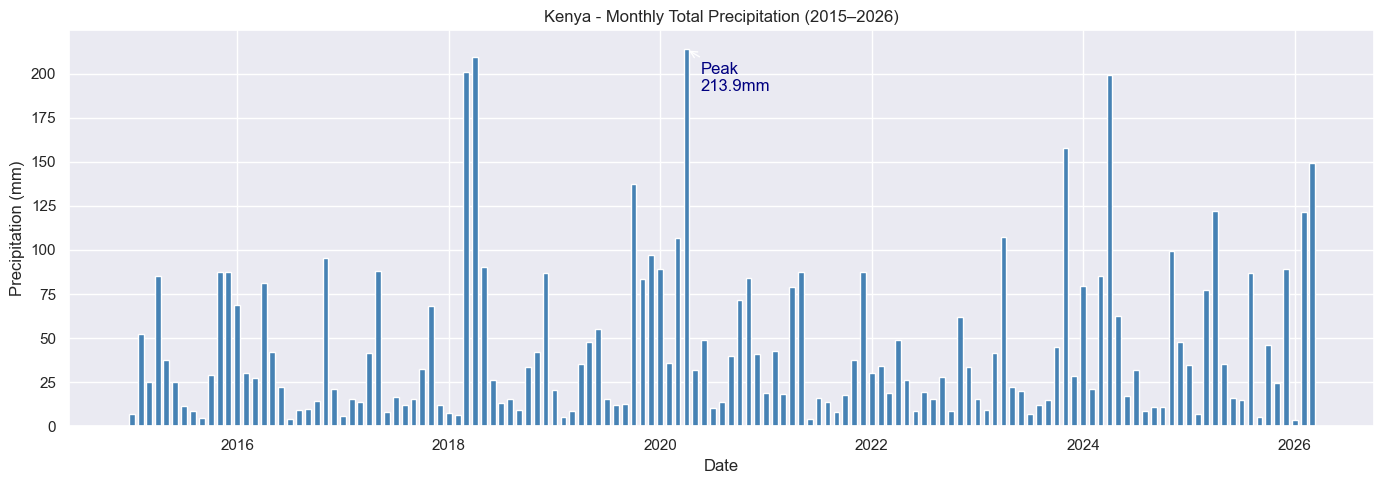

In [8]:
monthly_precip = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_precip["Date"] = pd.to_datetime(monthly_precip[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_precip["Date"], monthly_precip["PRECTOTCORR"], color="steelblue", width=20)

peak = monthly_precip.loc[monthly_precip["PRECTOTCORR"].idxmax()]
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(10, -30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="navy")

plt.title("Kenya - Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.savefig("notebooks/kenya_precip.png")
plt.show()

Precipitation Pattern Analysis

Kenya's precipitation chart reveals its characteristic bimodal rainfall 
pattern — two distinct rainy seasons per year rather than one. Peak 
monthly rainfall reached 213.9mm, with high rainfall months recurring 
roughly every six months. 

This bimodal structure is critical for Kenyan agriculture, as farmers 
plan two planting cycles around these seasons. Any shift in the timing 
or intensity of either rainy season directly threatens food security 
for millions of smallholder farmers. The chart also shows significant 
year-to-year variability in peak rainfall amounts, indicating growing 
climate unpredictability.

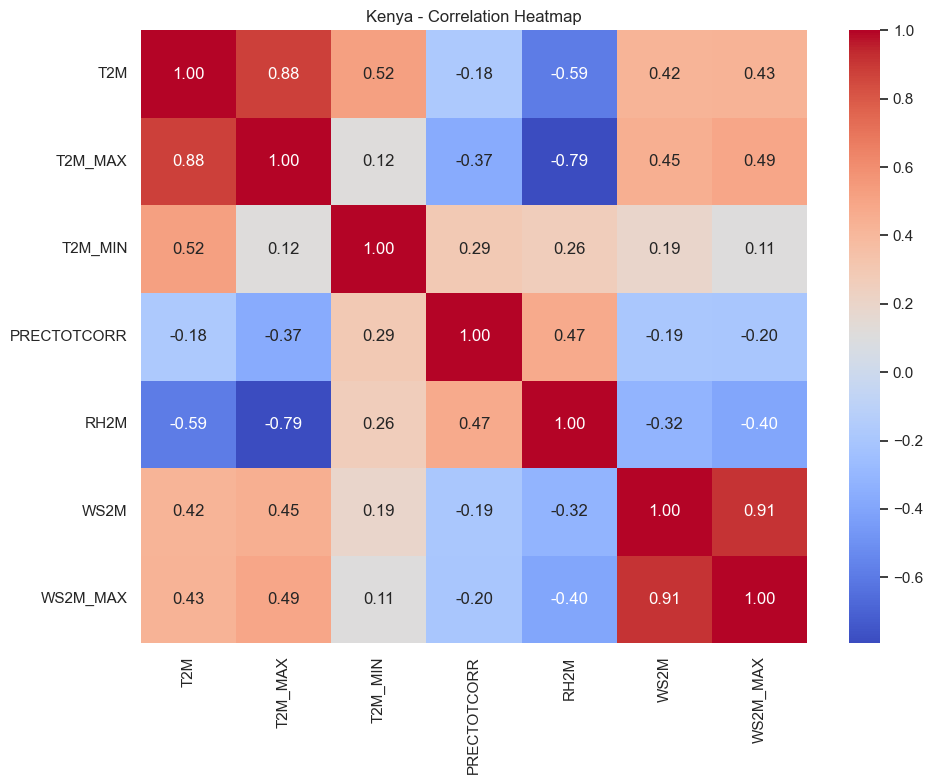

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Kenya - Correlation Heatmap")
plt.tight_layout()
plt.savefig("notebooks/kenya_corr.png")
plt.show()

T2M_MAX and RH2M (r = -0.79):** The strongest correlation in 
Kenya's data is between maximum daily temperature and relative humidity. 
When daily temperatures peak, humidity drops sharply — a compounding 
stress that increases heat index risk for outdoor workers and livestock 
during dry season months.

2. **T2M and T2M_MAX (r = +0.88):** Daily mean and maximum temperature 
are strongly positively correlated, confirming that hotter days are 
hotter across the full daily cycle, not just at peak hours. This 
amplifies the agricultural and health impact of warming trends.

3. **WS2M and WS2M_MAX (r = +0.91):** Mean and maximum wind speed are 
highly correlated, indicating that windier days are consistently windier 
throughout the day. This has implications for evapotranspiration rates 
and soil moisture loss during dry periods.

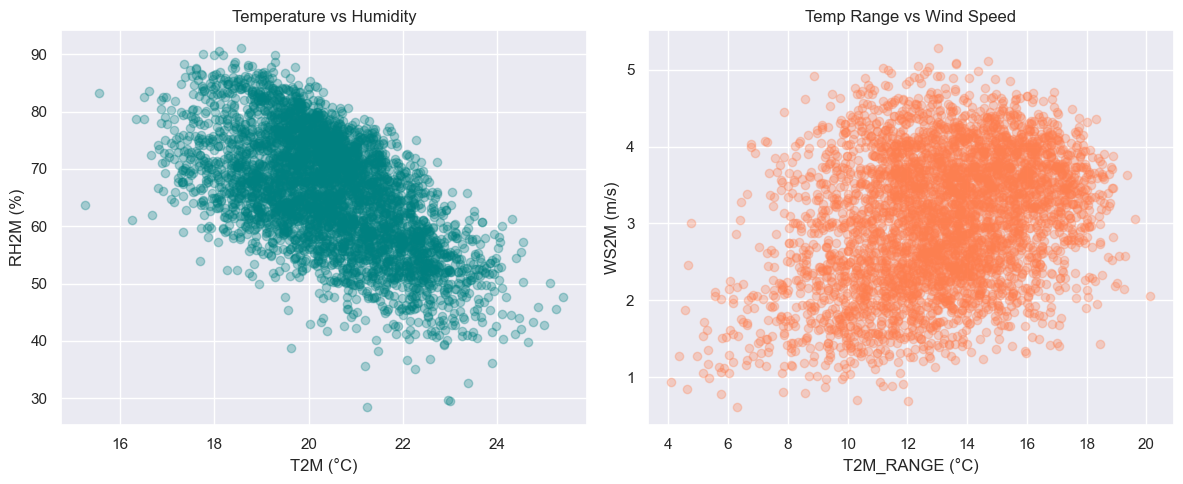

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="teal")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].set_title("Temperature vs Humidity")

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="coral")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].set_title("Temp Range vs Wind Speed")

plt.tight_layout()
plt.savefig("notebooks/kenya_scatter.png")
plt.show()

Precipitation Distribution Analysis

Kenya's daily precipitation is heavily right-skewed. The vast majority 
of days record zero or near-zero rainfall while a small number of days 
carry extreme totals. A log scale was applied to make the full 
distribution visible.

This skewed distribution means average rainfall statistics 
significantly overestimate day-to-day water availability. For 
Kenyan farmers, the practical reality is months of near-zero rainfall 
interrupted by intense but brief rainy periods. As climate change 
intensifies this pattern — fewer rainy days carrying more rainfall — 
the window for safe planting and harvesting continues to narrow.

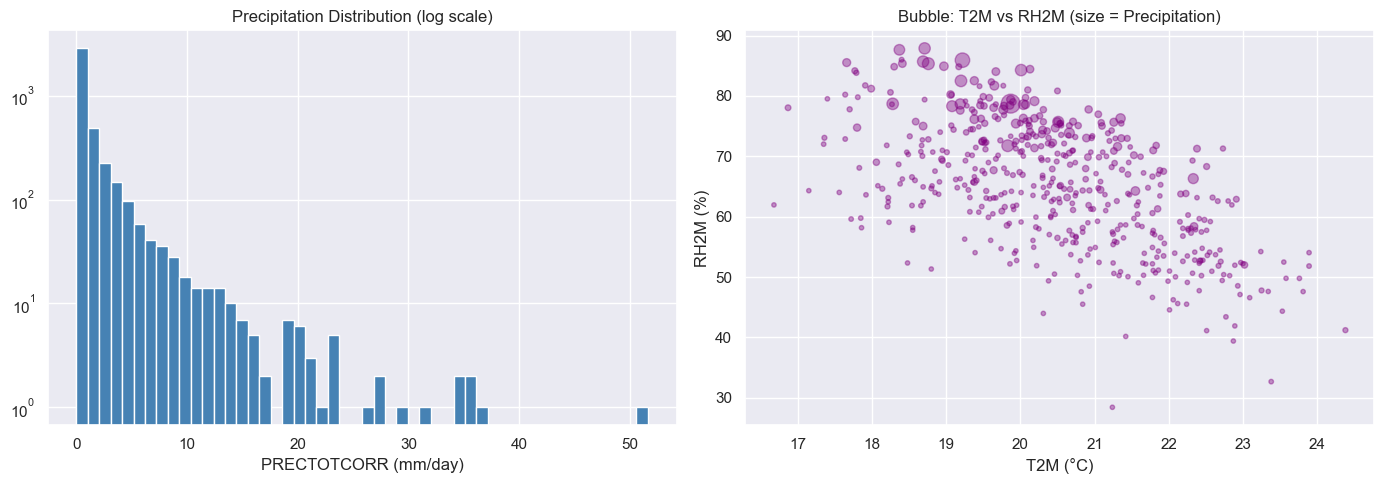

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale
axes[0].hist(df["PRECTOTCORR"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Precipitation Distribution (log scale)")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")

# Bubble chart
sample = df.sample(500, random_state=42)
axes[1].scatter(sample["T2M"], sample["RH2M"],
                s=sample["PRECTOTCORR"].fillna(0) * 5 + 10,
                alpha=0.4, color="purple")
axes[1].set_xlabel("T2M (°C)")
axes[1].set_ylabel("RH2M (%)")
axes[1].set_title("Bubble: T2M vs RH2M (size = Precipitation)")

plt.tight_layout()
plt.savefig("notebooks/kenya_dist.png")
plt.show()